## Step 2 - Create training and test data

We split the dataset into training and test data using an 80/20 split. The training set contains 2344 houses and is used for developing the solution, while the test set contains 586 houses and is kept separate until the final evaluation. A fixed random state of 42 is used so that the same split is produced every time the notebook is run.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../AmesHousing.csv")

train_df = df.sample(frac=0.8, random_state=42)


test_df = df.drop(train_df.index)

print("Training data:", train_df.shape)
print("Test data:", test_df.shape)

Training data: (2344, 82)
Test data: (586, 82)


In [2]:
print(train_df.columns.tolist())

['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck 

## Step 3 - Prepare the data
We separate `SalePrice` (the target, y) from the input features (X), so the price is not used as an input. We remove `Order` and `PID` because they are only ID numbers and contain no information about the house. After this step, the training set has 2344 houses and the test set has 586 houses, each with 79 features.

In [3]:
X_train = train_df.drop(columns=["SalePrice", "Order", "PID"])
y_train = train_df["SalePrice"]

X_test = test_df.drop(columns=["SalePrice", "Order", "PID"])
y_test = test_df["SalePrice"]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2344, 79) (2344,)
(586, 79) (586,)


In [4]:
X_train.isna().sum()

MS SubClass         0
MS Zoning           0
Lot Frontage      394
Lot Area            0
Street              0
                 ... 
Misc Val            0
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
Length: 79, dtype: int64

In [5]:
X_test.isna().sum()

MS SubClass        0
MS Zoning          0
Lot Frontage      96
Lot Area           0
Street             0
                  ..
Misc Val           0
Mo Sold            0
Yr Sold            0
Sale Type          0
Sale Condition     0
Length: 79, dtype: int64

We handled missing values based on the *Understanding the Dataset* guide, which describes two types of missing values. For numerical columns such as `Lot Frontage`, `Garage Area` and the basement areas, the guide says a missing value means "not recorded", so we treated it as unknown and filled it with the **median from the training data**. The median is not affected by extreme values, and the same training medians were applied to the test data to avoid data leakage. For categorical columns such as `Pool QC`, `Alley`, `Fence` and the garage/basement categories, a missing value means the house does not have the feature, so we filled them with "None".

In [6]:
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

X_train = X_train.fillna("None")
X_test = X_test.fillna("None")


`MS SubClass` contains numbers, but according to the dataset guide these are codes for house types (e.g. 20 = 1-story, 60 = 2-story), not real amounts. We converted it to text so the model treats it as a category instead of a number.

In [7]:
X_train["MS SubClass"] = X_train["MS SubClass"].astype(str)
X_test["MS SubClass"] = X_test["MS SubClass"].astype(str)

We standardised the numerical features using the **mean and standard deviation from the training data**, and applied the same values to the test data. Scaling puts features with very different ranges (e.g. `Lot Area` and `Overall Qual`) on a similar scale, which mainly helps Linear Regression. Using only training statistics avoids data leakage.

In [8]:
num_cols = X_train.select_dtypes("number").columns
means = X_train[num_cols].mean()
stds = X_train[num_cols].std().replace(0, 1)

X_train[num_cols] = (X_train[num_cols] - means) / stds
X_test[num_cols] = (X_test[num_cols] - means) / stds

The models need numbers, so we one-hot encoded the categorical features with `pd.get_dummies`. We used `drop_first=True` to remove one redundant column per category, and removed rare categories that occur in fewer than 10 houses in the training data. Without these steps, Linear Regression gave extreme predictions on the test data (R² ≈ −6 × 10²⁰), because nearly identical and very rare columns received extreme weights. Finally, the test set was reindexed so it has exactly the same columns as the training set.

In [9]:
X_train = pd.get_dummies(X_train, dtype=int, drop_first=True)
X_test = pd.get_dummies(X_test, dtype=int, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Remove rare categories: fewer than 10 houses in TRAIN
rare = [c for c in X_train.columns if c not in num_cols and X_train[c].sum() < 10]
X_train = X_train.drop(columns=rare)
X_test = X_test.drop(columns=rare)
print("Fjernet sjeldne kolonner:", len(rare))

Fjernet sjeldne kolonner: 64


In [10]:
print(X_train.shape, X_test.shape)

(2344, 222) (586, 222)


## Step 4 - Select and engineer features

In [11]:
# Calculate correlation between every training feature and SalePrice
correlations = X_train.corrwith(y_train)

# Remove any NaN correlations, for example from constant columns
correlations = correlations.dropna()

# Sort by absolute correlation strength
sorted_features = correlations.abs().sort_values(ascending=False)

# Keep the original positive/negative correlation values
correlations_sorted = correlations.loc[sorted_features.index]

print(correlations_sorted.head(40))

Overall Qual              0.800899
Gr Liv Area               0.708011
Garage Cars               0.644341
Garage Area               0.636100
Total Bsmt SF             0.628642
1st Flr SF                0.622572
Exter Qual_TA            -0.600075
Year Built                0.565191
Full Bath                 0.550182
Kitchen Qual_TA          -0.534700
Year Remod/Add            0.532479
Foundation_PConc          0.528599
Garage Yr Blt             0.517895
Mas Vnr Area              0.506701
TotRms AbvGrd             0.500629
Fireplace Qu_None        -0.476589
Fireplaces                0.466477
BsmtFin Type 1_GLQ        0.464112
Bsmt Qual_TA             -0.454907
Exter Qual_Gd             0.454258
BsmtFin SF 1              0.436995
Garage Finish_Unf        -0.432475
Neighborhood_NridgHt      0.429454
Mas Vnr Type_None        -0.398642
Fireplace Qu_Gd           0.377759
Garage Type_Detchd       -0.367282
Foundation_CBlock        -0.360246
MS SubClass_60            0.356883
Sale Type_New       

In [12]:
weak_features = correlations[
    correlations.abs() < 0.05
].sort_values()

print(weak_features.to_string())

MS SubClass_85          -0.049268
Condition 1_RRAe        -0.047654
Exterior 1st_Stucco     -0.046842
Exterior 1st_Plywood    -0.045929
Exterior 2nd_Brk Cmn    -0.045889
BsmtFin Type 2_BLQ      -0.044431
Sale Condition_Alloca   -0.043049
House Style_SLvl        -0.042360
Roof Style_Gambrel      -0.042197
Fence_MnWw              -0.041598
Neighborhood_NPkVill    -0.040764
Neighborhood_Mitchel    -0.040725
Condition 2_Norm        -0.038290
Sale Condition_Family   -0.037900
MS SubClass_80          -0.036642
BsmtFin Type 2_LwQ      -0.036611
Low Qual Fin SF         -0.035896
Fireplace Qu_Fa         -0.031810
Heating_GasW            -0.031262
Bsmt Half Bath          -0.027775
Yr Sold                 -0.023456
House Style_1Story      -0.021318
Functional_Mod          -0.020054
Lot Config_FR2          -0.015953
Misc Val                -0.011513
Alley_Pave              -0.008382
House Style_2.5Unf      -0.006674
Exterior 1st_BrkFace    -0.005325
Exterior 2nd_BrkFace    -0.004363
BsmtFin SF 2  

Correlation analysis showed that features such as Overall Quality, Above Ground Living Area, Garage Cars, Garage Area and Total Basement Area had strong relationships with SalePrice. Several encoded categorical levels showed weak individual correlations. However, these levels belong to larger categorical variables and a weak Pearson correlation does not necessarily mean that the feature is not useful, particularly for the Decision Tree and Random Forest models. Therefore, features were not removed solely based on a correlation threshold. Order and PID were removed because they are identifiers rather than meaningful house characteristics.

In [13]:
top_features = correlations_sorted.head(15)

top_features_df = pd.DataFrame({
    "Feature": top_features.index,
    "Correlation with SalePrice": top_features.values
})

top_features_df

,Feature,Correlation with SalePrice
0,Overall Qual,0.800899
1,Gr Liv Area,0.708011
2,Garage Cars,0.644341
3,Garage Area,0.636100
4,Total Bsmt SF,0.628642
5,1st Flr SF,0.622572
6,Exter Qual_TA,-0.600075
7,Year Built,0.565191
8,Full Bath,0.550182
9,Kitchen Qual_TA,-0.534700


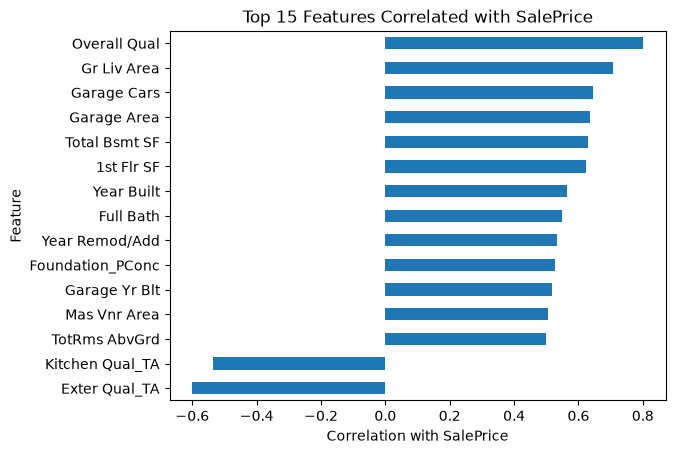

In [14]:
import matplotlib.pyplot as plt

top_features.sort_values().plot(kind="barh")

plt.xlabel("Correlation with SalePrice")
plt.ylabel("Feature")
plt.title("Top 15 Features Correlated with SalePrice")
plt.show()

## Step 5 – Train the models
We imported the three regression models required by the assignment from scikit-learn: LinearRegression, DecisionTreeRegressor and RandomForestRegressor. They were used with default settings (no hyperparameter tuning), as required. All three models were trained on the same prepared training data (`X_train`, `y_train`), so that their test results can be compared fairly. We set `random_state=42` for the tree-based models so the results are reproducible. The test data was not used during training.


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [16]:
lin_reg = LinearRegression()
tree_reg = DecisionTreeRegressor(random_state=42)
forest_reg = RandomForestRegressor(random_state=42)

lin_reg.fit(X_train, y_train)
tree_reg.fit(X_train, y_train)
forest_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Step 6 – Evaluate the models on the test data
We evaluated all three models on the unseen test data using RMSE and R². RMSE shows the typical prediction error in US dollars (lower is better). R² compares the model with simply predicting the mean price (1 = perfect, 0 = no better than the mean).

| Model | Test RMSE | Test R² |
|---|---|---|
| Linear Regression | 24 840 | 0.891 |
| Decision Tree Regression | 31 598 | 0.824 |
| Random Forest Regression | 23 173 | 0.905 |

Random Forest performed best, with the lowest RMSE and the highest R². With an average test price of about $179 000, its typical error is about 13% of the average price. Linear Regression was close behind. Decision Tree performed worst: it had R² ≈ 1.0 on the training data but only 0.82 on the test data, which shows overfitting. Random Forest reduces this by averaging many trees.

In [17]:
forest_reg.score(X_test, y_test)

0.9050853049818864

In [18]:
lin_reg.score(X_test, y_test)

0.8909600793722949

In [19]:
tree_reg.score(X_test, y_test)

0.8235219620262095

In [20]:
test_df["SalePrice"].mean()

np.float64(179040.43686006826)

In [21]:
print("Linear:", np.sqrt(mean_squared_error(y_test, lin_reg.predict(X_test))))
print("Tree:  ", np.sqrt(mean_squared_error(y_test, tree_reg.predict(X_test))))
print("Forest:", np.sqrt(mean_squared_error(y_test, forest_reg.predict(X_test))))

Linear: 24837.4138569163
Tree:   31597.952646122838
Forest: 23172.89740288143
